# Proof embeddings at controlled coupling strength — p90, 2026-10-06

Question: if coupling strength is neutralised per recording, do the baselines (mean absolute correlation; the mean of each SPI, $m$) lose the class structure that SPI–SPI $z$ keeps? Answer from this run: mean $|r|$ alone falls to chance, and the geometry of $m$ degrades where strength varies between recordings, most clearly among CML regimes; but $m$ never becomes uninformative, and setting strength to one common value changes nothing. Exploratory; arms were fixed before p90, the $M=24$ repeat was added after the $M=16$ outcome.

In [1]:
from pathlib import Path
import sys, warnings
import matplotlib.pyplot as plt, pandas as pd
ROOT = Path.cwd().resolve()
while not (ROOT / 'src').is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
warnings.filterwarnings('ignore')
from scripts import proof_strength_nuisance as P
rows, bank = P.load('m16'); OUT = ROOT / 'results/proof' / P.RUNS['m16']['run']; cache = {}
print(f"{len(rows)} recordings; {len(bank['spi_order'])} SPIs; {bank['z'].shape[1]:,} SPI-SPI coordinates; M=16, T=1000")

1680 recordings; 289 SPIs; 41,616 SPI-SPI coordinates; M=16, T=1000


Eight coupled classes (two ring VARs at spectral radius .98, Kuramoto at partial synchrony, the wave equation, four CML regimes) and the two independent-noise references, 40 realizations each. Every arm observes the same realization through white sensor noise of SD $\eta$ (signal-SD units), which attenuates all dependence together; arms differ only in how $\eta$ is chosen. `native`: none. `equalised`: $\eta$ solves mean $|r|=.14$. `mild`: $\eta\sim U[.3,.9]$. `matched`: $\eta$ solves mean $|r|=s$ with $s\sim U[.08,.20]$, the same distribution in every class. `wide`: Pearson attenuation $1/(1+\eta^2)\sim U[.25,.95]$. `mild` and `wide` are independent of class; `equalised` and `matched` need more noise for natively stronger classes.

Noise can lower strength but not raise it. A recording natively weaker than its target is left as generated: 55% of fully developed turbulence (native mean $|r|\approx.13$) in `matched`, 92% of it in `equalised`, at most 12% of any other class. The noise classes have no coupling to attenuate and join every arm unchanged. Features and preprocessing follow the proof notebook; $m$ is additionally scaled to unit variance and clipped at five SD because SPI units differ. Each arm and panel is fitted separately and without labels.

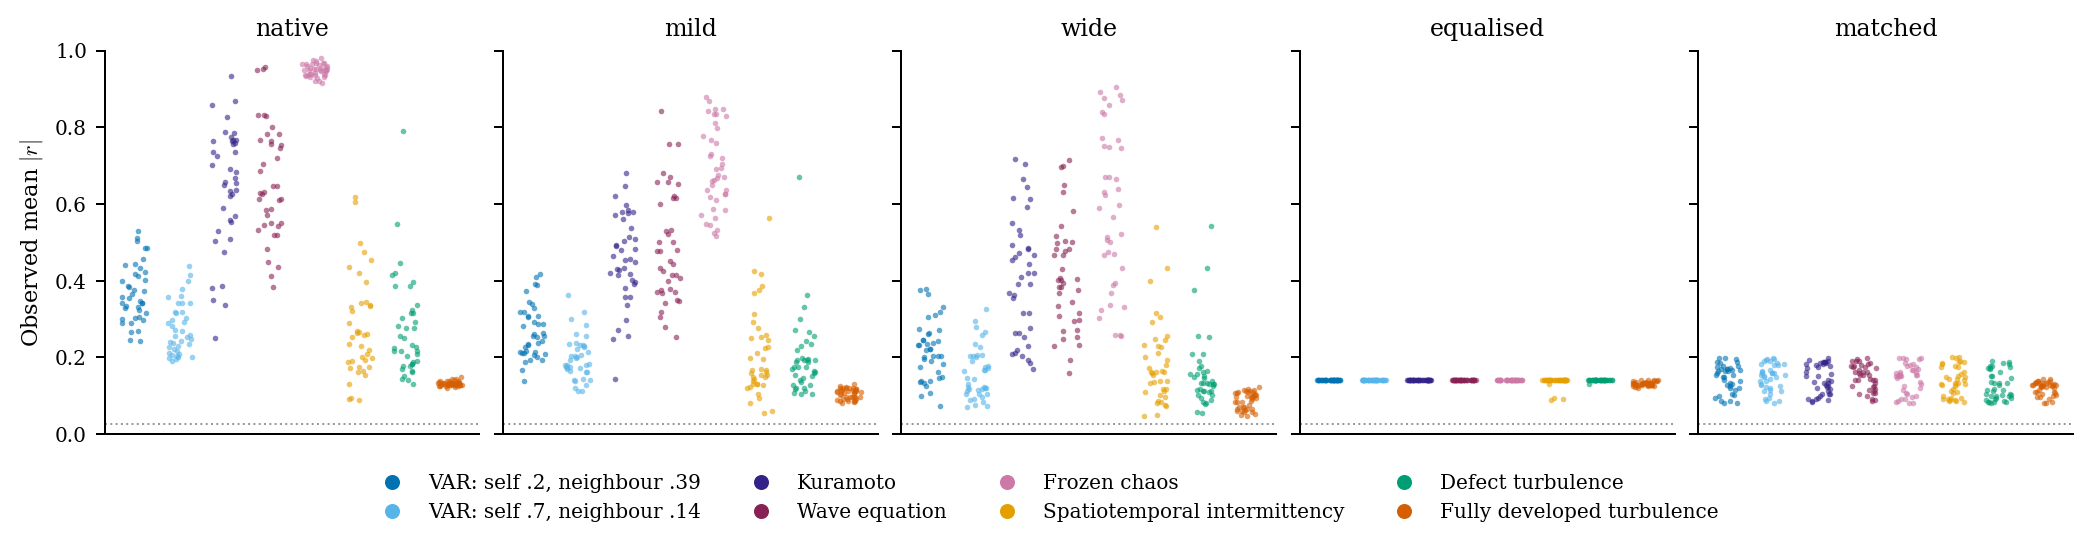

In [2]:
fig = P.strength_figure(rows, OUT); plt.show()

Within CML. Rows are arms. Fixed strength (`native`, `equalised`) leaves both representations clustered. Once strength varies between recordings (`matched`, `wide`) the mean vectors spread along it and their UMAP loses separate clusters; $z$ keeps four.

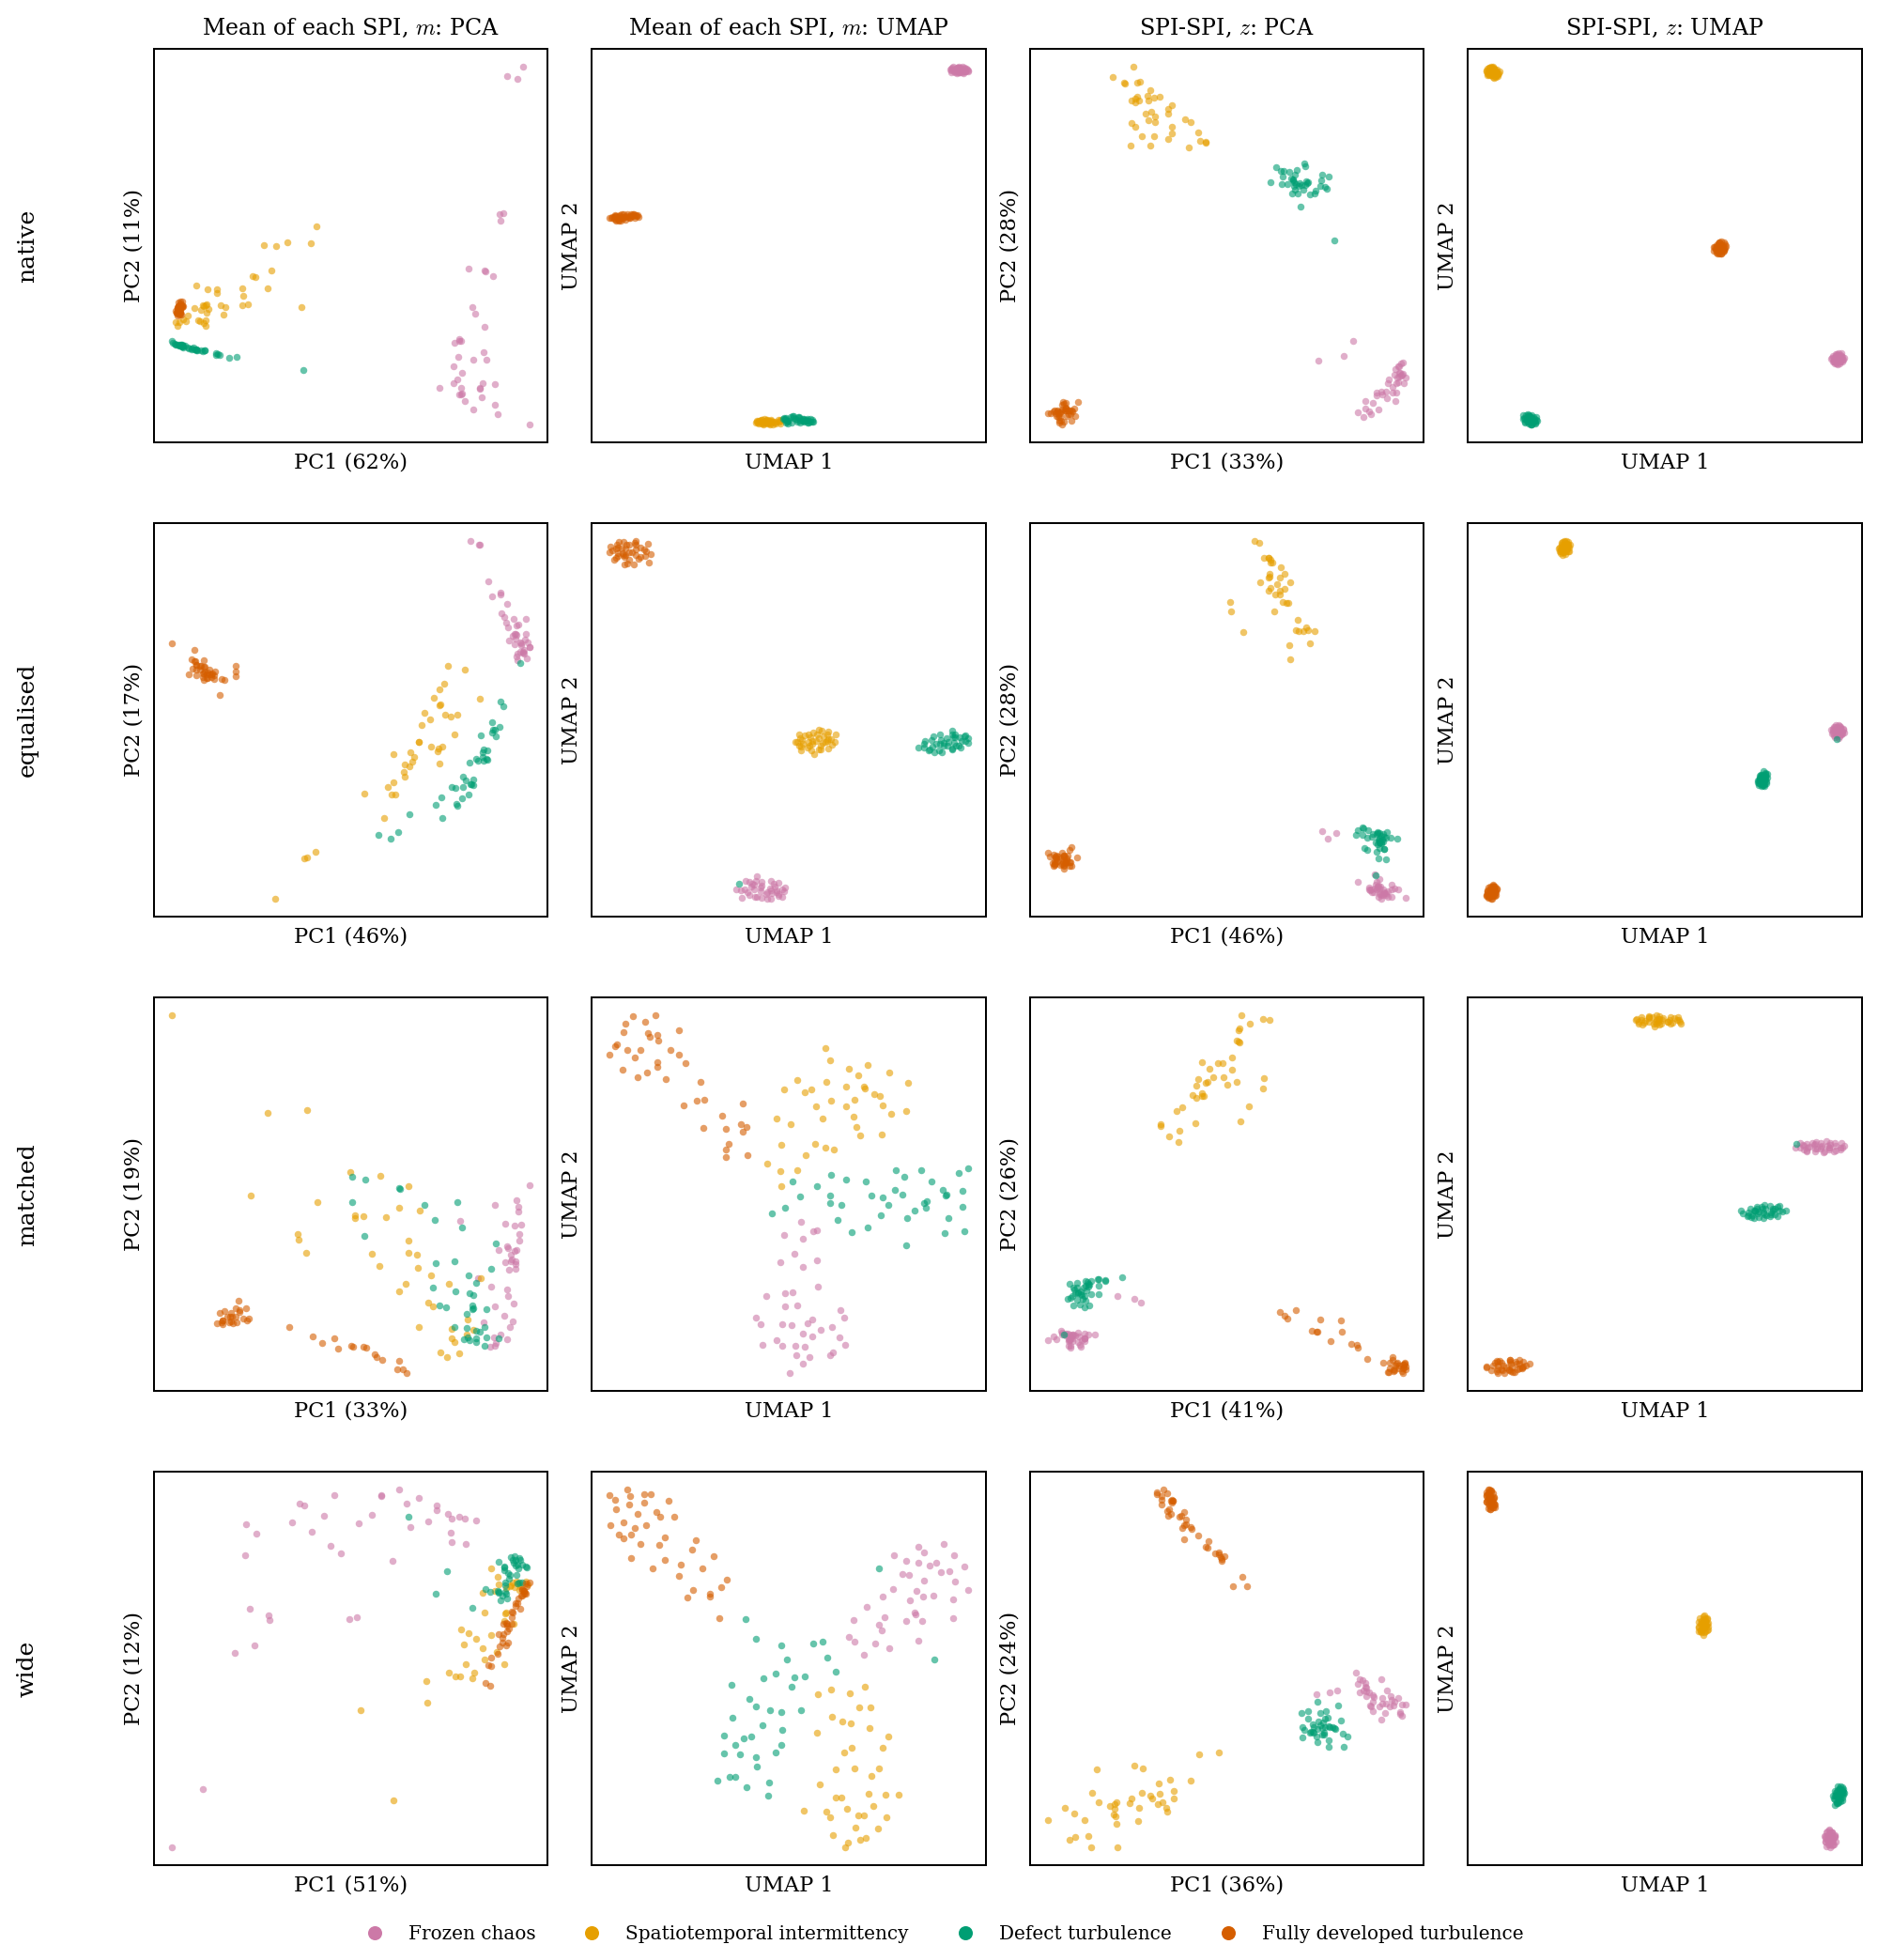

In [3]:
fig = P.embedding_figure(rows, bank, 'cml', ('native', 'equalised', 'matched', 'wide'), OUT, cache=cache); plt.show()

The same two varying-strength arms coloured by observed mean $|r|$: strength is a gradient across the mean embedding and is mixed within each $z$ cluster.

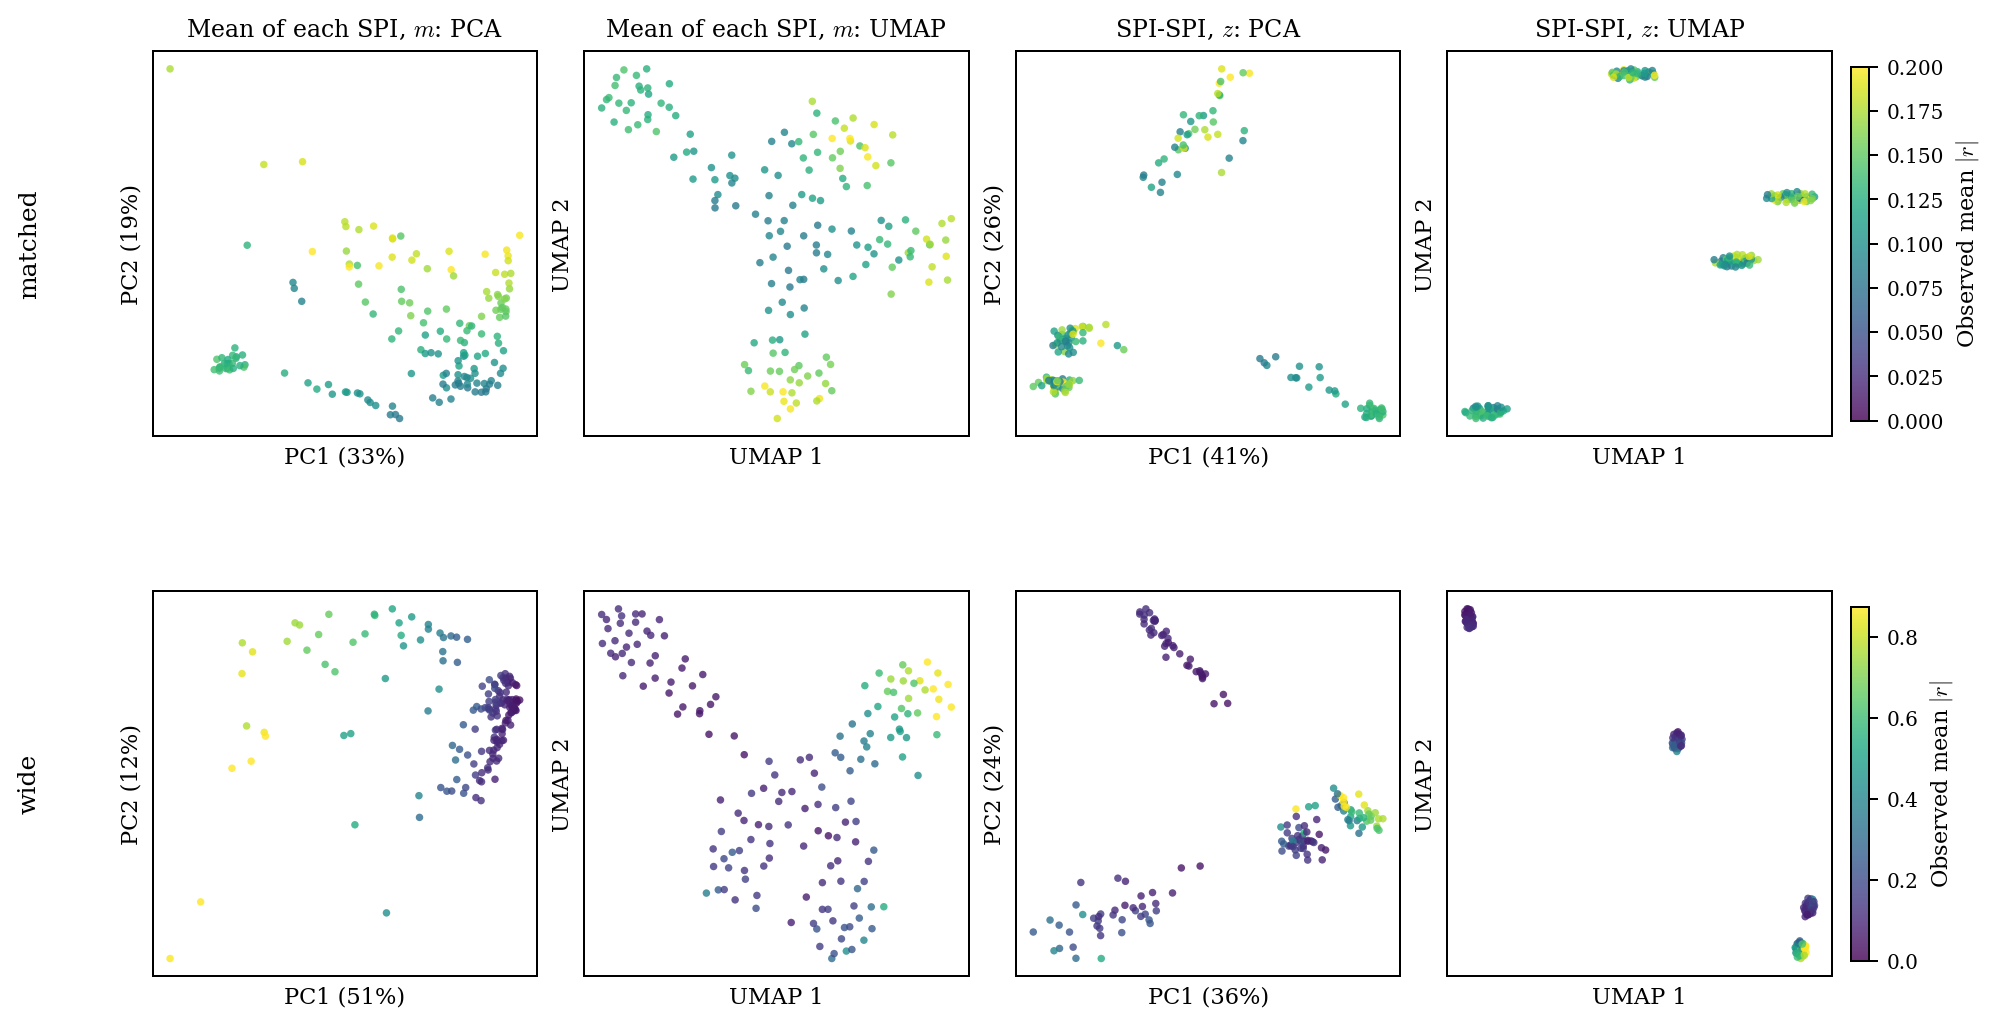

In [4]:
fig = P.embedding_figure(rows, bank, 'cml', ('matched', 'wide'), OUT, color='strength', cache=cache); plt.show()

Feature by feature in the `wide` arm, where noise level is independent of class: how closely each coordinate follows strength among recordings of one class. Most SPI means follow it; most $z$ coordinates do not, though a minority do, so $z$ is less sensitive to strength rather than blind to it.

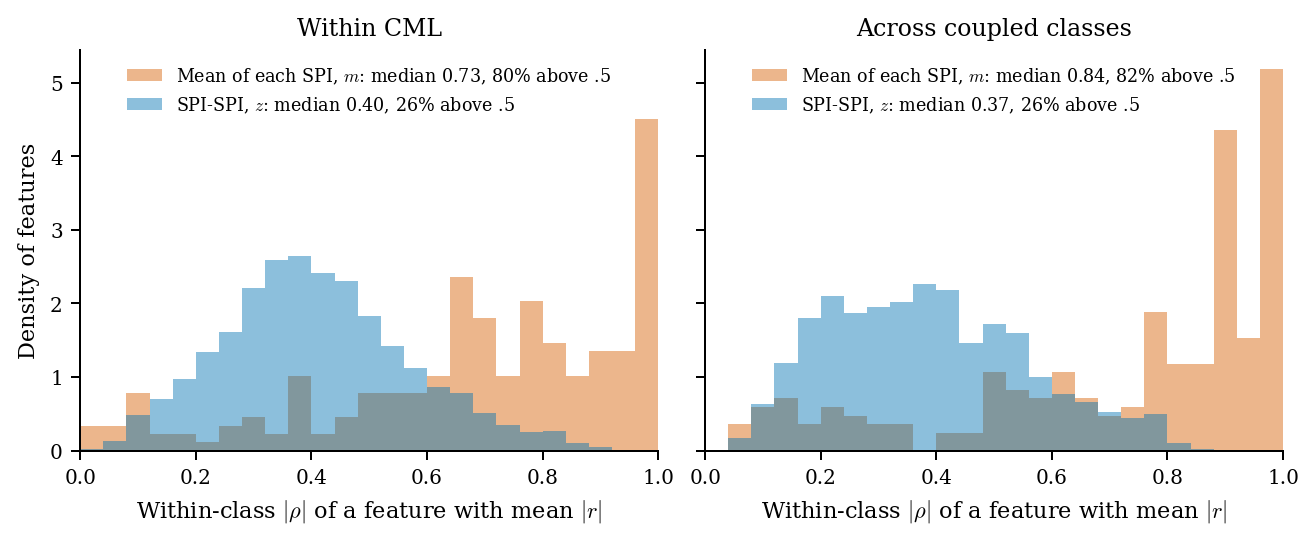

In [5]:
fig = P.dependence_figure(rows, bank, 'wide', OUT); plt.show()

Across classes. Strength variation turns the mean PCA into overlapping streaks, but the families differ in far more than strength and the mean UMAP still separates them. Under heavy noise neither representation separates the two VARs from Kuramoto in two dimensions.

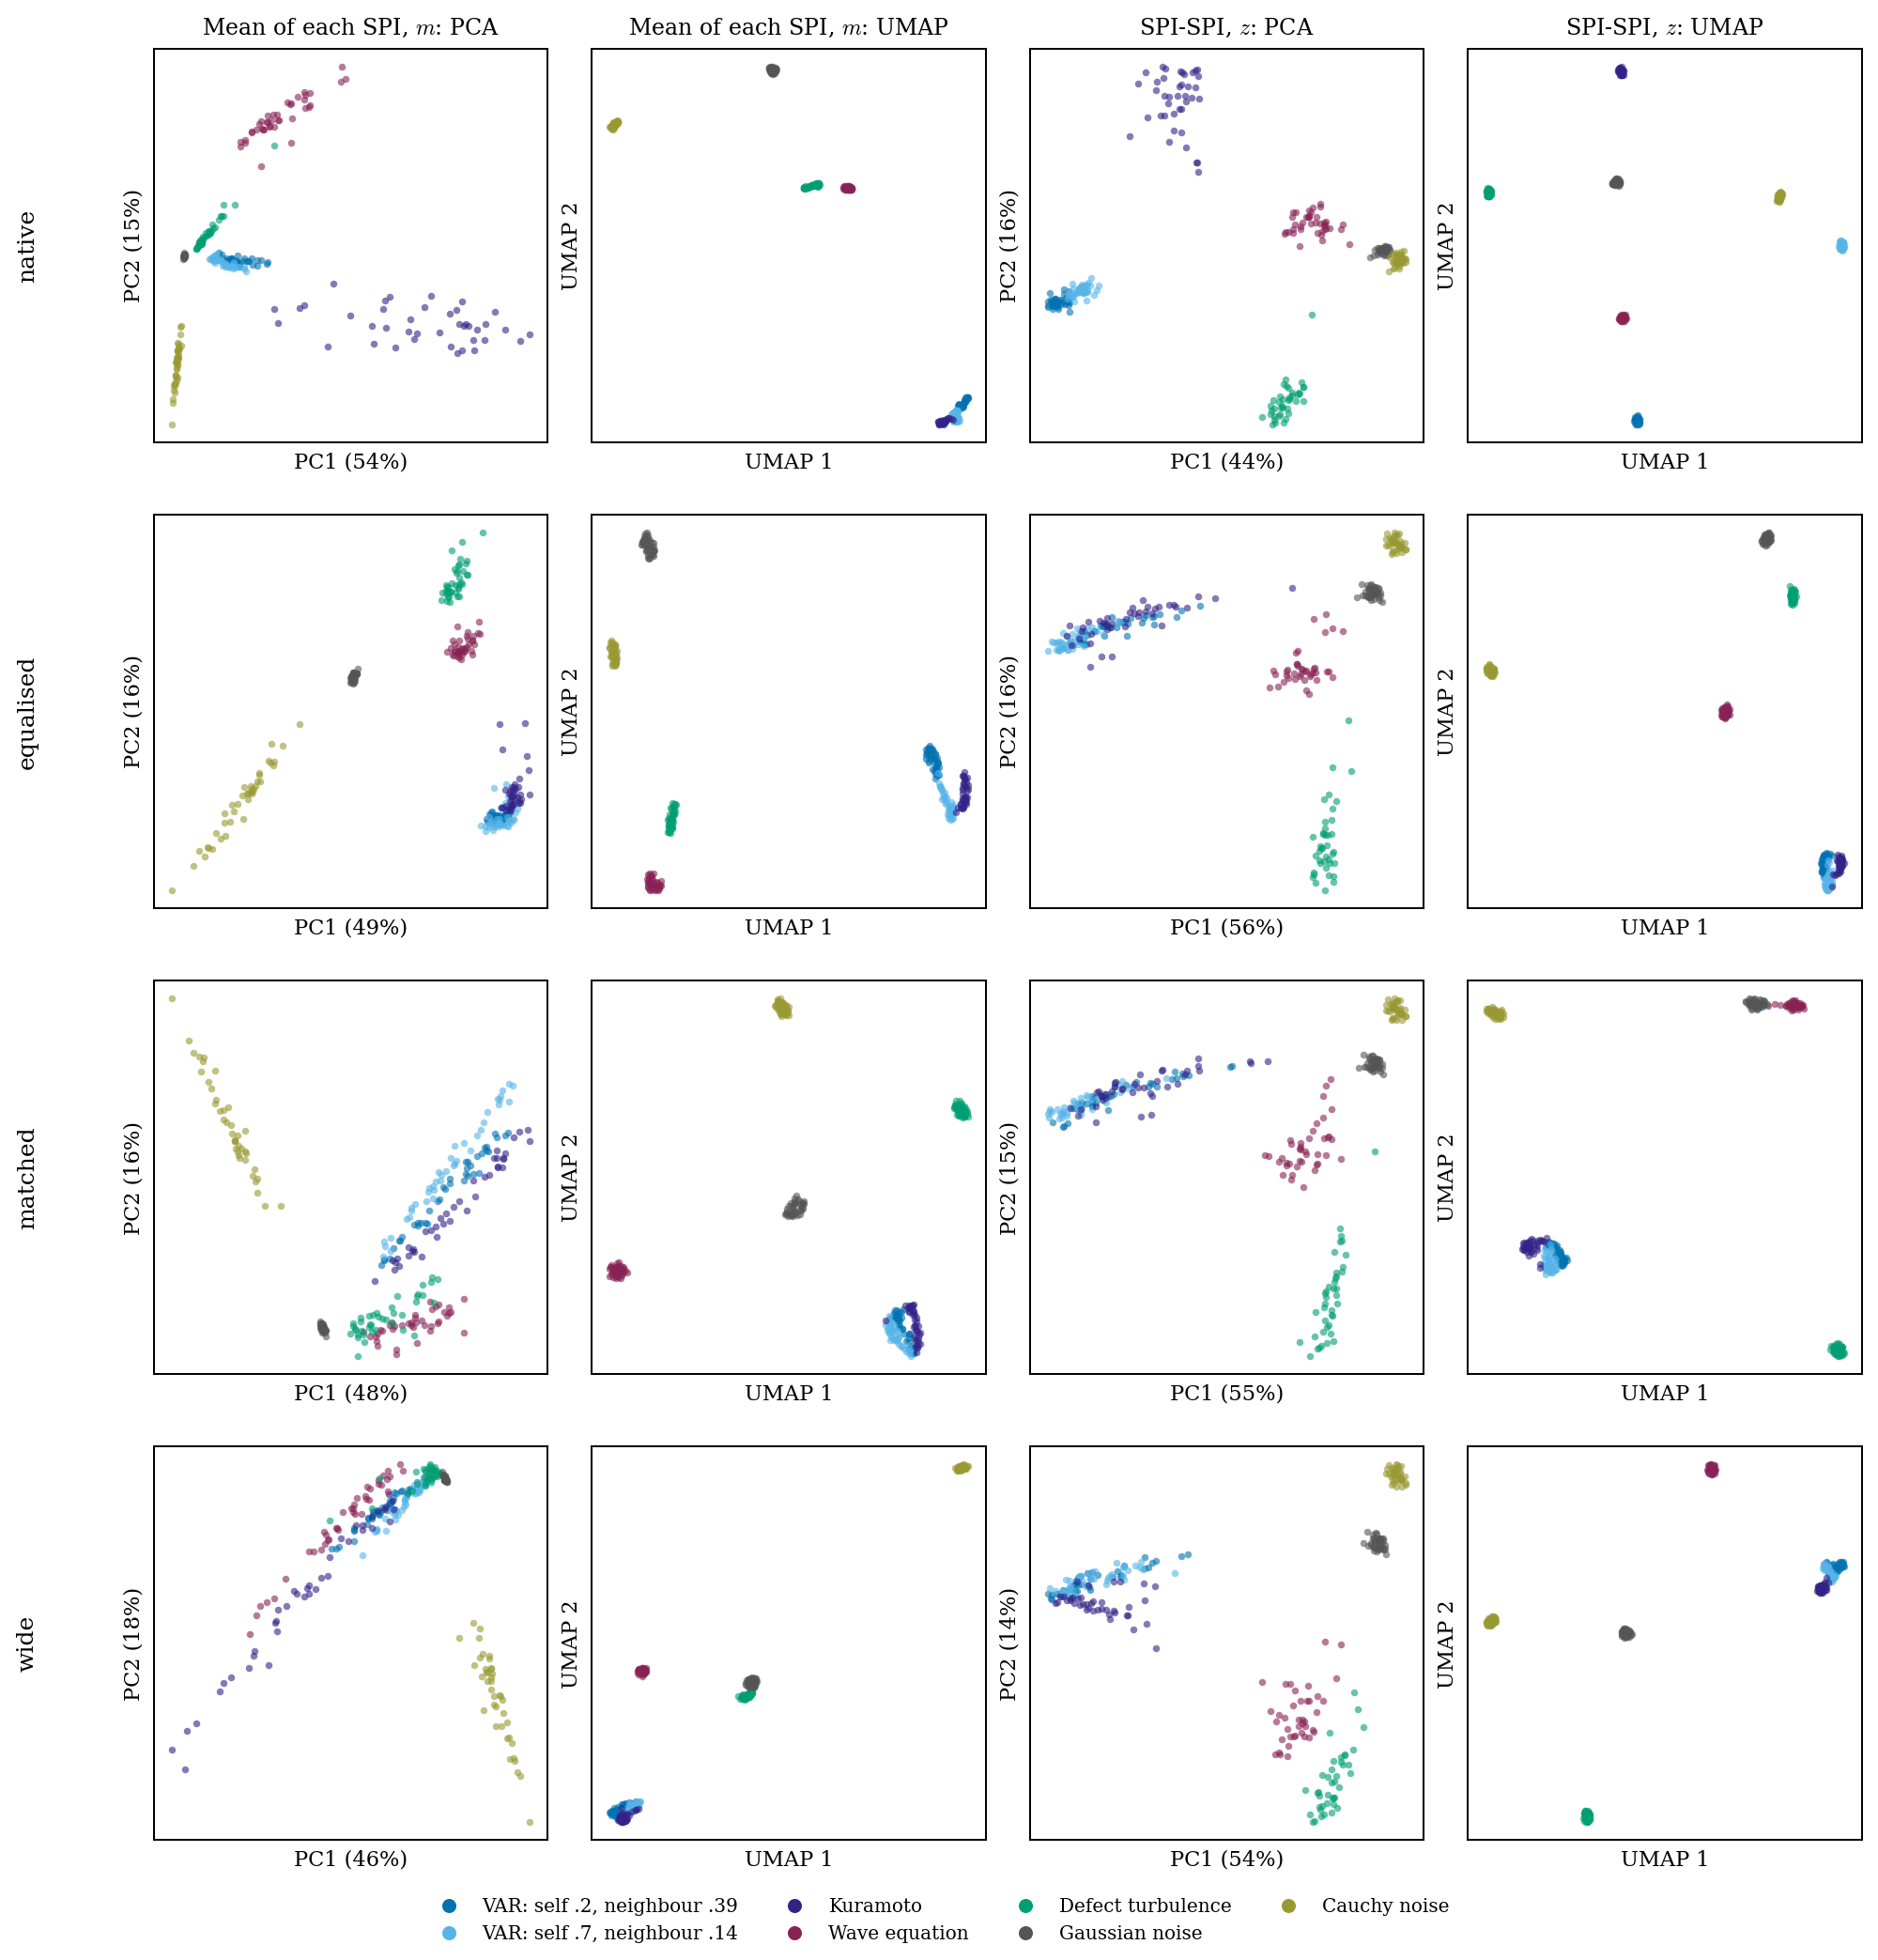

In [6]:
fig = P.embedding_figure(rows, bank, 'inter', ('native', 'equalised', 'matched', 'wide'), OUT, cache=cache); plt.show()

Scores in the 50-PC space of each fit, against class labels that the fit never saw. Silhouette measures cluster compactness; neighbour agreement is the share of each recording's five nearest neighbours in its own class (dotted: chance). `pooled` fits all five arms together. The dashed curve drops the leading component of $m$, the obvious repair once that component is strength.

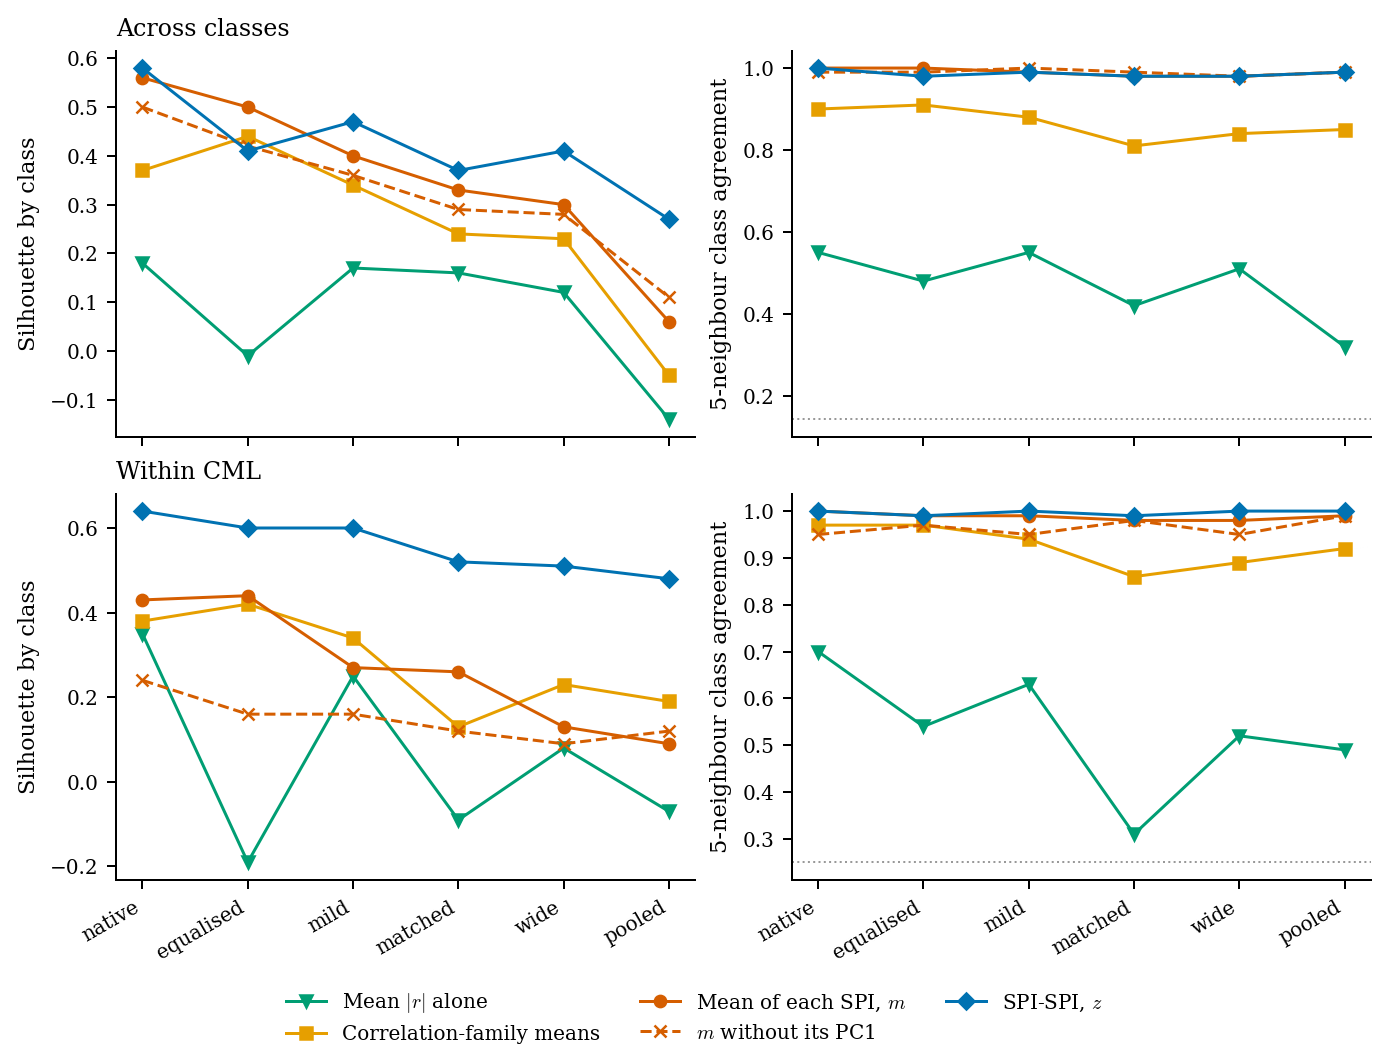

{('native', 'inter'): (0.02, 0.01, 0.03), ('equalised', 'inter'): (-0.09, -0.1, -0.08), ('matched', 'inter'): (0.04, 0.03, 0.06), ('wide', 'inter'): (0.11, 0.09, 0.13), ('native', 'cml'): (0.21, 0.2, 0.23), ('equalised', 'cml'): (0.16, 0.15, 0.17), ('matched', 'cml'): (0.25, 0.23, 0.27), ('wide', 'cml'): (0.38, 0.36, 0.4)}


In [7]:
m = P.metrics(rows, bank); m.to_csv(OUT / 'metrics.csv', index=False)
fig = P.metrics_figure(m, OUT); plt.show()
for panel in P.PANELS:
    display(pd.concat({c: P.table(m, panel, c) for c in ('silhouette', 'purity', 'ceiling')}, axis=1).loc[['strength', 'mean', 'z']].style.format('{:.2f}').set_caption(panel))
print({(a, p): tuple(round(float(v), 2) for v in P.silhouette_gap(rows, bank, a, p)) for p in P.PANELS for a in ('native', 'equalised', 'matched', 'wide')})

The last line is the silhouette of $z$ minus that of $m$ with a 95% interval from resampling realizations (embeddings held fixed). `ceiling` is grouped five-fold logistic accuracy on ten PCs. The within-CML ordering does not depend on how either representation is scaled:

In [8]:
P.sensitivity(rows, bank, 'cml')

,native,equalised,mild,matched,wide
"m, unit variance (shown)",0.43,0.44,0.27,0.26,0.13
"m, interquartile range",0.35,0.40,0.23,0.22,0.14
"m, rank-Gaussian",0.39,0.39,0.30,0.28,0.24
"z, centred (shown)",0.64,0.60,0.60,0.52,0.51
"z, unit variance",0.54,0.47,0.44,0.39,0.34


Fresh-seed repeat at $M=24$, `native` and `matched` only. Native strengths are lower at this size, so more recordings are left as generated (78% of fully developed turbulence).

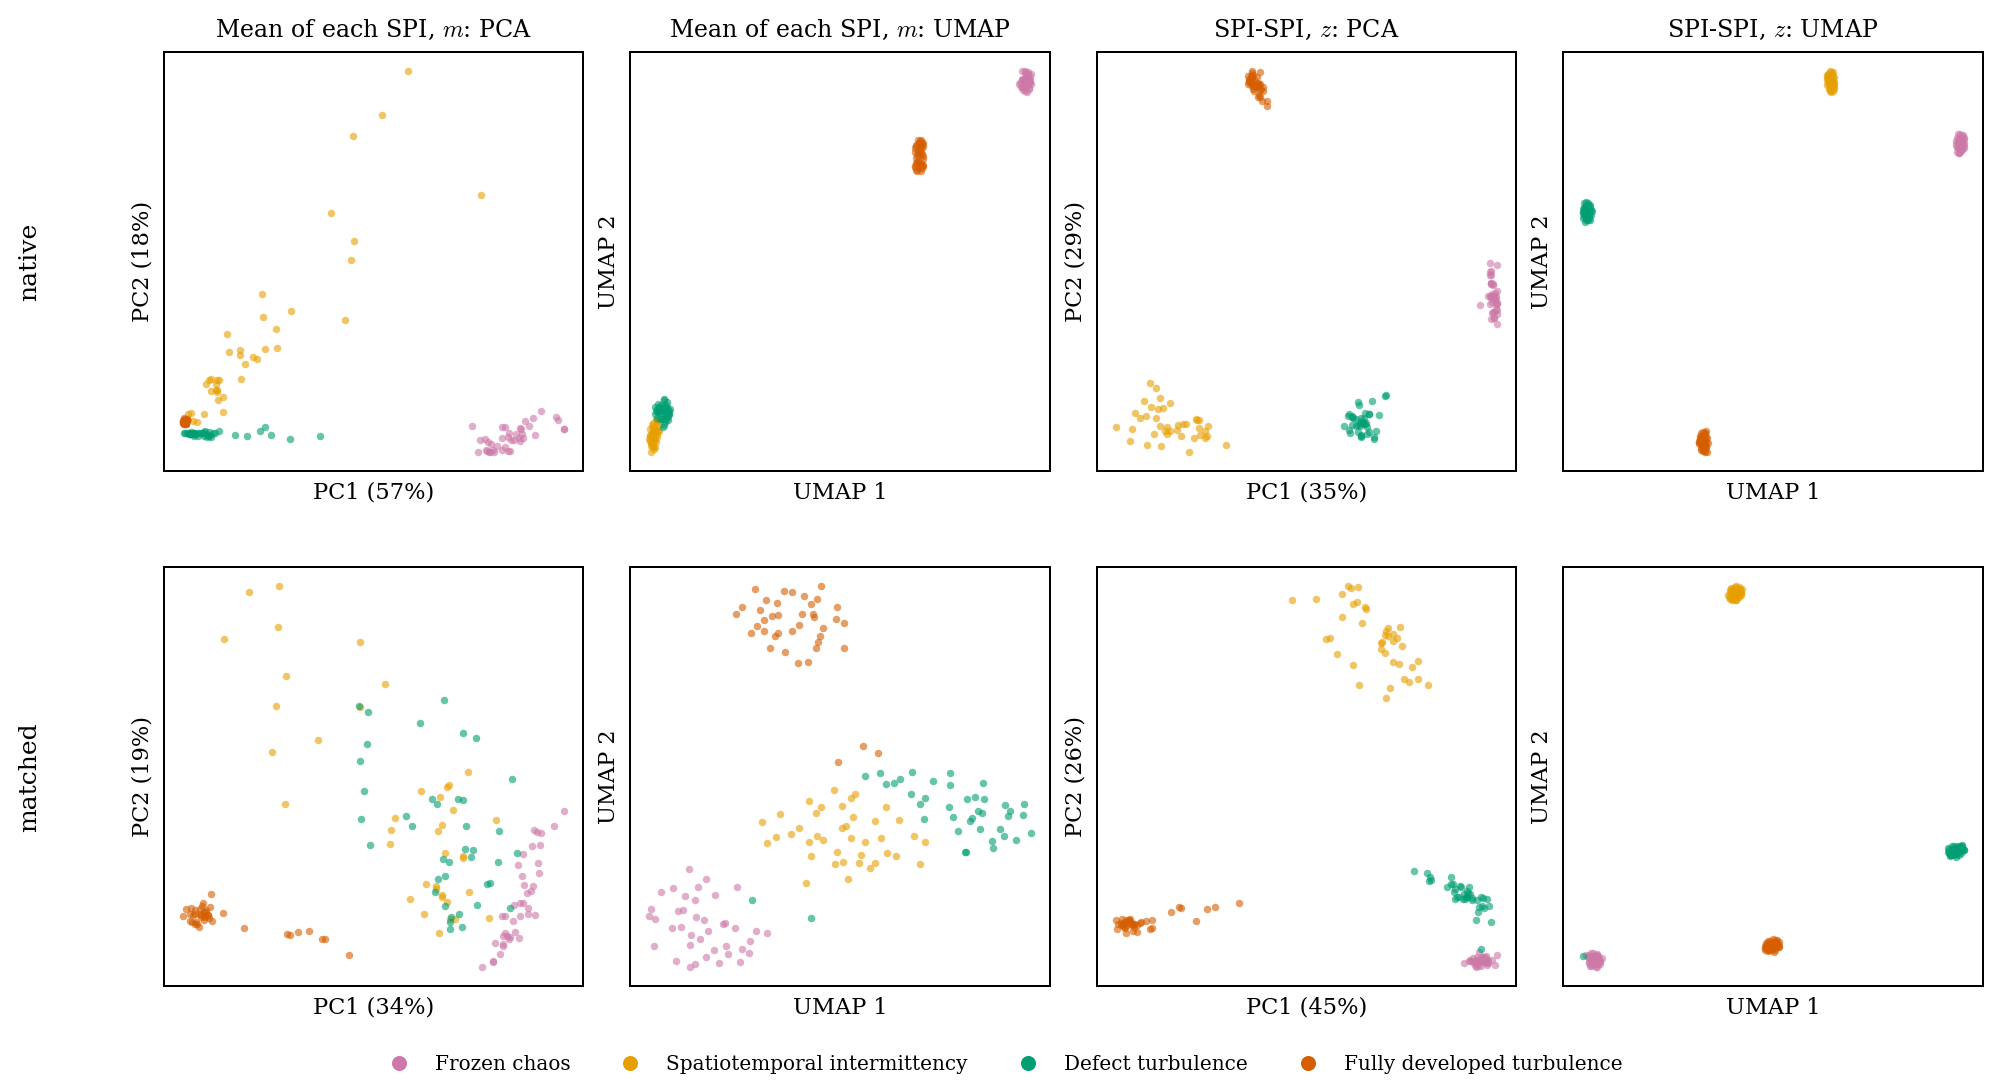

{('native', 'inter'): (0.06, 0.05, 0.07), ('matched', 'inter'): (0.07, 0.05, 0.09), ('native', 'cml'): (0.25, 0.24, 0.27), ('matched', 'cml'): (0.28, 0.27, 0.3)}


In [9]:
rows24, bank24 = P.load('m24'); OUT24 = ROOT / 'results/proof' / P.RUNS['m24']['run']
fig = P.embedding_figure(rows24, bank24, 'cml', ('native', 'matched'), OUT24); plt.show()
m24 = P.metrics(rows24, bank24); m24.to_csv(OUT24 / 'metrics.csv', index=False)
for panel in P.PANELS:
    display(pd.concat({c: P.table(m24, panel, c) for c in ('silhouette', 'purity', 'ceiling')}, axis=1).loc[['strength', 'mean', 'z']].style.format('{:.2f}').set_caption(panel + ', M=24'))
print({(a, p): tuple(round(float(v), 2) for v in P.silhouette_gap(rows24, bank24, a, p)) for p in P.PANELS for a in ('native', 'matched')})

**Reading.**

- *Mean absolute correlation* carries no class information once strength is matched (within CML: neighbour agreement .31 at $M=16$, .38 at $M=24$; chance .25).
- *Equalising strength does not neutralise $m$.* With mean $|r|$ fixed at .14 in every class, $m$ is as clustered as natively (CML silhouette .44 against .43) and across classes more compact than $z$ (.50 against .41). Equal mean $|r|$ does not equalise 289 means: they are responses of different detectors and encode character. Earlier matched-strength runs found the same.
- *Strength that varies between recordings is what degrades $m$.* Within CML the silhouette of $m$ falls to .26 (`matched`) and .13 (`wide`) while $z$ holds .52 and .51; at $M=24$, .32 against .61. Within a class 80% of SPI means follow strength ($|\rho|>.5$) against 26% of $z$ coordinates.
- *$m$ never becomes noise.* Neighbour agreement and supervised accuracy stay at or above .98 for both representations in every arm, and removing the leading component of $m$ does not restore compactness. The supported contrast is the unsupervised geometry, not the information.
- *Qualifications.* $z$ is already more compact than $m$ within CML without any nuisance (silhouette gap .21; .25 `matched`, .38 `wide`), so only the growth of the gap is attributable to strength, and at $M=24$ that growth is small (.25 to .28). Across classes the gap is small in every arm. `equalised` and `matched` add more noise to natively stronger classes, which either representation may exploit; `mild` and `wide` do not. One nuisance (white, equal on all channels), one length.

Why: $z_{ab}$ is unchanged when each SPI's profile across pairs is shifted and rescaled, per recording. Standardising every profile within a recording therefore sets every mean to zero and leaves $z$ exactly as it was, so $z$ is by construction what remains once the set of strengths is removed. Equal sensor noise on all channels approximates such a rescaling for second-order statistics (attenuation by measurement error), which is why $z$ moves less; it also lowers the reliability of each profile and pulls $z$ toward its independent-noise value, which is the residual strength dependence seen above.

Run: `scripts/proof_strength_nuisance.py` (`prepare`, external-corpus farm, `extract`); this notebook is rebuilt by `scripts/build_proof_strength_notebook.py`. Full p90, estimator seeds 261102 and 261112, 2,400 recordings, none failed.